<a href="https://colab.research.google.com/github/4Unknown-user/AIML-Assignment_3/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Clustering Evaluation Metrics ---
Silhouette Score: 0.8756
Davies-Bouldin Index: 0.1737


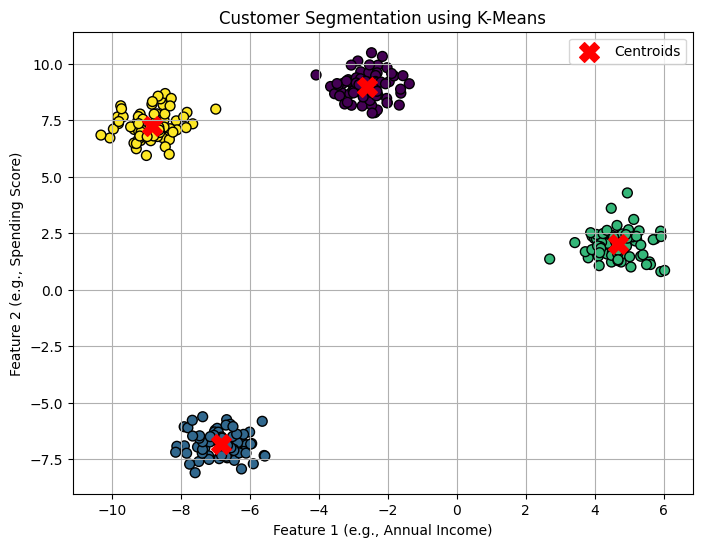

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels = kmeans.fit_predict(df)

df['Cluster'] = labels

sil_score = silhouette_score(df[['Feature_1', 'Feature_2']], labels)
db_score = davies_bouldin_score(df[['Feature_1', 'Feature_2']], labels)

print("--- Clustering Evaluation Metrics ---")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(df['Feature_1'], df['Feature_2'], c=df['Cluster'], cmap='viridis', marker='o', edgecolor='k', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('Customer Segmentation using K-Means')
plt.xlabel('Feature 1 (e.g., Annual Income)')
plt.ylabel('Feature 2 (e.g., Spending Score)')
plt.legend()
plt.grid(True)
plt.show()